### RaschPy SLM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 20 items, 40% missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.SLM_Sim(no_of_items=10, no_of_persons=40, item_range=2, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:20, 5:] = float('nan')   # first 20 persons: only answer items 1-5
responses_disconnected.iloc[20:, :5] = float('nan')    # last 20 persons: only answer items 6-10

broken_slm = rp.SLM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/slm.py:168: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 5): ['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5']; Sub-group 2 (size 5): ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52437/847616553.py:6: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_slm = rp.SLM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_slm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5'],
  ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.SLM_Sim(no_of_items=20, no_of_persons=1000, missing=0.4, seed=42)
sim.responses.to_csv('slm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_slm()` to load and validate it — it coerces values to 0/1 and flags anything else as missing. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_slm('slm_scores.csv')

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20
Person_1,NaN,0.0,NaN,1.0,NaN,0.0,0.0,1.0,0.0,NaN,0.0,NaN,NaN,NaN,1.0,0.0,NaN,1.0,0.0,NaN
Person_2,NaN,NaN,NaN,0.0,1.0,1.0,0.0,NaN,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20


Create an SLM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `slm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame (e.g. `rp.SLM(data)`) instead.

In [8]:
slm = rp.SLM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
slm.calibrate()

CPU times: user 1.08 ms, sys: 545 μs, total: 1.63 ms
Wall time: 1.34 ms


Check the item location estimates - view the first two items

In [10]:
slm.items.head(2)

Item_1    0.827957
Item_2   -0.243022
dtype: float64

Since this is simulated data, we know the true generating item locations (`slm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE:

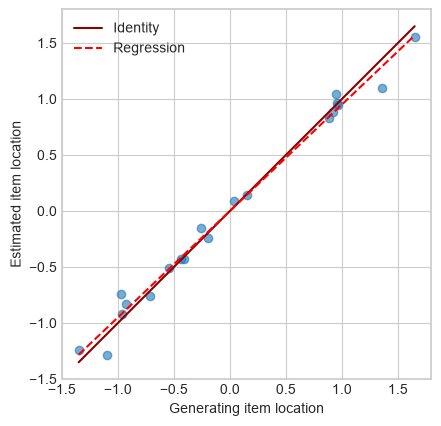

item location Pearson correlation:              0.994
item location SD ratio (estimated / generating): 0.956
item location regression coefficient:            0.95
item location RMSE:                              0.105


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(slm.generating.items, slm.items, 'item location', 'my_slm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
slm.item_stats_df()
slm.item_stats.to_csv('slm_item_stats.csv')

CPU times: user 638 ms, sys: 38.4 ms, total: 676 ms
Wall time: 678 ms


Check the item statistics table - view the first two items

In [13]:
slm.item_stats.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,0.828,0.109,596,0.351,0.960,0.935
Item_2,-0.243,0.102,596,0.565,0.913,0.866


Generate a table of person statistics (and check run time), and save to file

In [14]:
%%time
slm.person_stats_df()
slm.person_stats.to_csv('slm_person_stats.csv')

CPU times: user 5.3 ms, sys: 830 μs, total: 6.13 ms
Wall time: 6.01 ms


Check the person statistics table - view the first two items

In [15]:
slm.person_stats.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,-0.542,0.664,4,11,0.364,1.260,1.057,1.256,0.848
Person_2,-1.588,0.664,3,14,0.214,0.829,-0.469,0.635,-0.536


And the same recovery check for person locations, against `slm.generating.persons`:

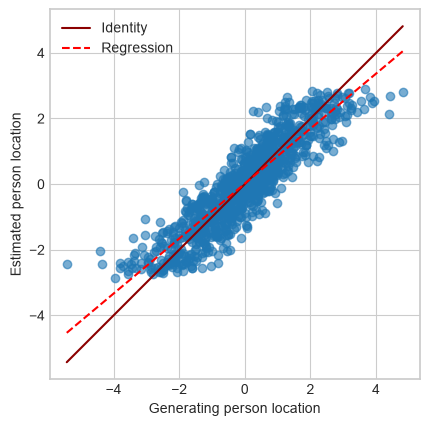

person location Pearson correlation:              0.899
person location SD ratio (estimated / generating): 0.932
person location regression coefficient:            0.838
person location RMSE:                              0.651


In [16]:
recovery_plot(slm.generating.persons, slm.persons, 'person location', 'my_slm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [17]:
%%time
slm.test_stats_df()
slm.test_stats.to_csv('slm_test_stats.csv')

CPU times: user 831 μs, sys: 440 μs, total: 1.27 ms
Wall time: 1.14 ms


Check the test statistics table

In [18]:
slm.test_stats

,Items,Persons
Mean,-0.000,0.017
SD,0.877,1.383
Separation ratio,8.377,1.758
Strata,11.503,2.678
Reliability,0.986,0.756


Run a residual correlation analysis (and check run time), and save relevant output to file

In [19]:
%%time
slm.res_corr_analysis()
slm.residual_correlations.to_csv('slm_residual_correlations.csv')
slm.loadings.to_csv('slm_loadings.csv')

CPU times: user 7.63 ms, sys: 2.01 ms, total: 9.64 ms
Wall time: 13.8 ms


View the table of pairwise standard residual correlations

In [20]:
slm.residual_correlations

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20
Item_1,1.000000,-0.111593,-0.169168,-0.042411,-0.074393,-0.064024,-0.042947,-0.016722,-0.110300,-0.090367,-0.071373,-0.135354,-0.108686,-0.044116,-0.139587,-0.122136,-0.022231,-0.084648,-0.038375,-0.091037
Item_2,-0.111593,1.000000,-0.058656,-0.070804,-0.189110,-0.036219,-0.136767,-0.046445,-0.027379,-0.116535,-0.018675,-0.100074,-0.086021,-0.104193,-0.201910,-0.098581,0.031058,-0.073290,-0.007423,-0.039084
Item_3,-0.169168,-0.058656,1.000000,-0.019605,-0.097026,-0.069208,-0.087569,-0.099425,-0.112632,-0.141923,-0.112063,-0.130290,-0.097961,-0.084375,-0.021720,-0.070009,-0.121380,-0.133700,-0.070628,-0.098088
Item_4,-0.042411,-0.070804,-0.019605,1.000000,-0.023714,-0.046262,-0.153267,-0.068368,-0.045177,-0.075893,-0.086946,-0.176394,-0.154361,-0.229354,0.008318,-0.128830,-0.011172,-0.084275,-0.040988,-0.130658
Item_5,-0.074393,-0.189110,-0.097026,-0.023714,1.000000,-0.142299,-0.116468,-0.065563,-0.080879,-0.056717,-0.127034,-0.047947,-0.060788,-0.168508,-0.081764,-0.162241,-0.031323,-0.065674,-0.027499,-0.079865
Item_6,-0.064024,-0.036219,-0.069208,-0.046262,-0.142299,1.000000,-0.132928,-0.140516,-0.014893,-0.135564,0.070730,-0.014155,0.006734,-0.052568,-0.110082,-0.146863,-0.030990,-0.036351,0.037247,-0.145198
Item_7,-0.042947,-0.136767,-0.087569,-0.153267,-0.116468,-0.132928,1.000000,-0.053332,-0.054803,-0.012383,-0.046541,-0.103002,-0.031319,-0.048022,0.001028,-0.113504,-0.119029,-0.101779,-0.108044,-0.042953
Item_8,-0.016722,-0.046445,-0.099425,-0.068368,-0.065563,-0.140516,-0.053332,1.000000,-0.092308,-0.039908,-0.190914,-0.173033,0.052638,-0.028473,-0.045721,-0.051728,-0.110266,-0.091038,-0.121862,-0.095585
Item_9,-0.110300,-0.027379,-0.112632,-0.045177,-0.080879,-0.014893,-0.054803,-0.092308,1.000000,-0.037206,-0.134334,-0.033464,-0.146179,-0.130973,-0.140538,-0.021693,-0.061839,-0.052650,-0.105135,-0.127861
Item_10,-0.090367,-0.116535,-0.141923,-0.075893,-0.056717,-0.135564,-0.012383,-0.039908,-0.037206,1.000000,-0.149173,-0.081575,0.006000,-0.055299,-0.099682,0.018341,-0.055443,-0.084504,-0.077951,-0.149220


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [21]:
slm.loadings['PC 1']

Item_1    -0.014203
Item_2    -0.089356
Item_3    -0.026570
Item_4    -0.100597
Item_5    -0.018748
Item_6    -0.115201
Item_7     0.073668
Item_8     0.103599
Item_9    -0.017163
Item_10    0.099798
Item_11   -0.118149
Item_12    0.002675
Item_13    0.083264
Item_14    0.120903
Item_15    0.039498
Item_16    0.117785
Item_17   -0.051498
Item_18    0.039074
Item_19   -0.104413
Item_20   -0.007947
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the threshold (item location) marked

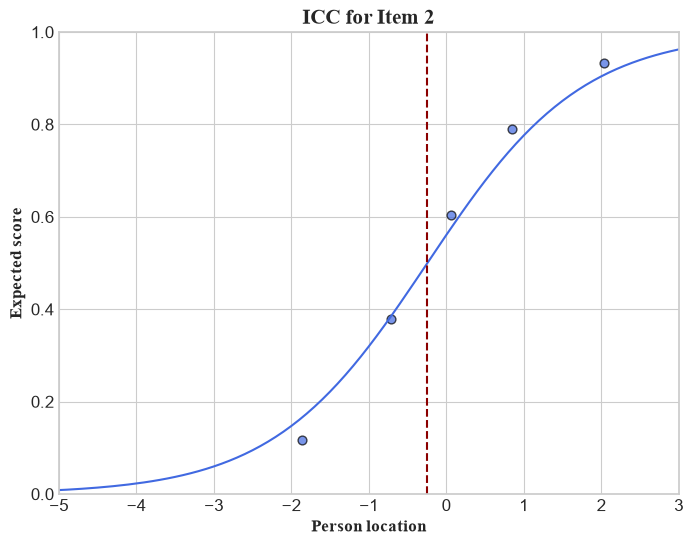

In [22]:
slm.icc('Item_2', title='ICC for Item 2', obs=True, thresh_line=True, xmin=-5, xmax=3, filename='my_slm_icc')

Produce an item information function curve for Item 2

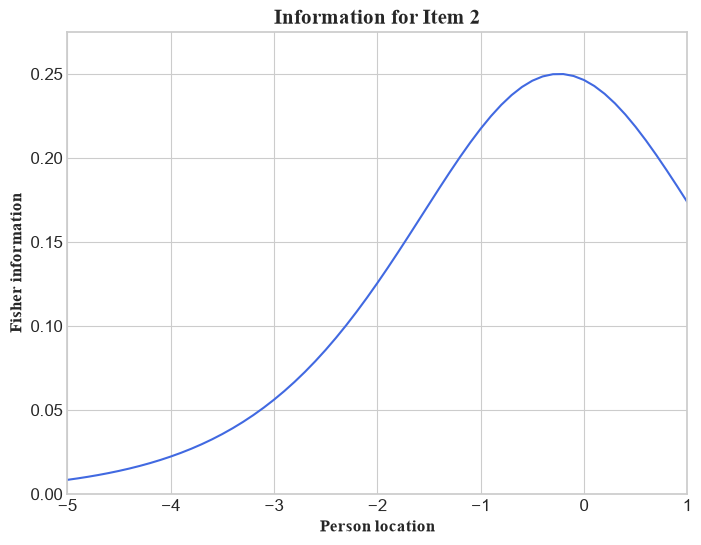

In [23]:
slm.iic('Item_2', title='Information for Item 2', xmin=-5, xmax=1, filename='my_slm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 10 and 15 plotted.

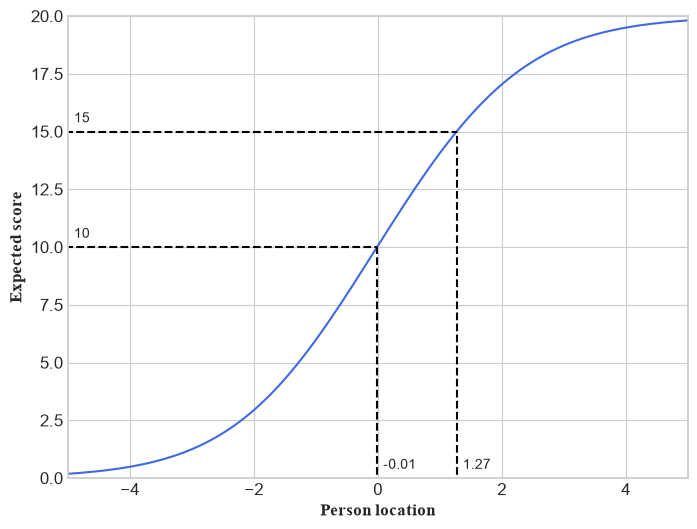

In [24]:
slm.tcc(score_lines=[10, 15], score_labels=True, filename='my_slm_tcc')

Produce a test information curve

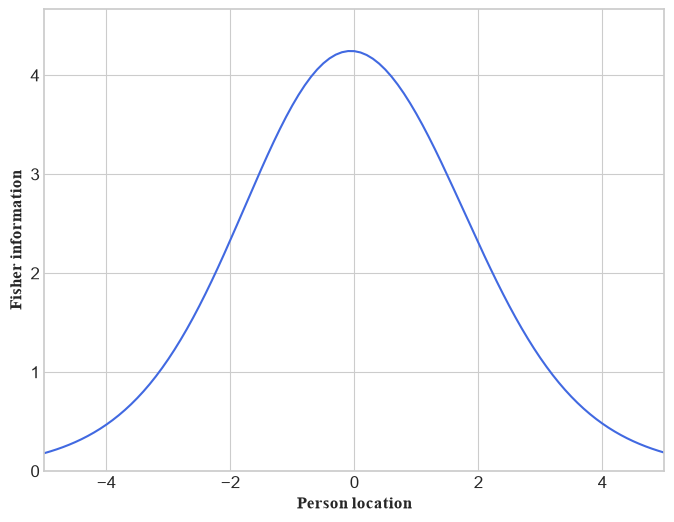

In [25]:
slm.test_info(filename='my_slm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

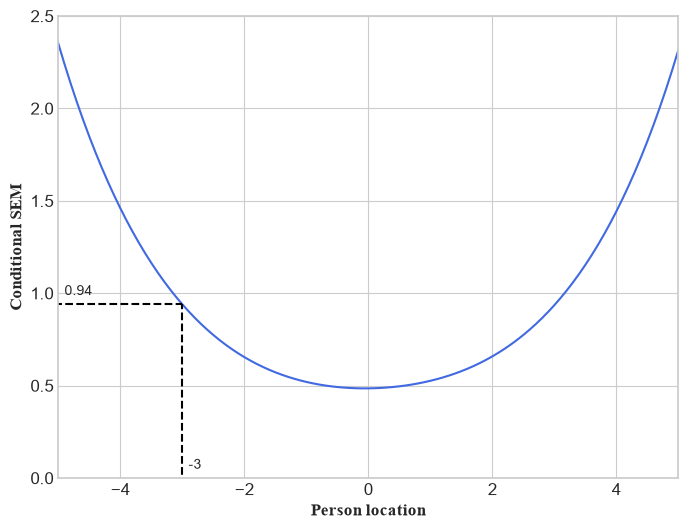

In [26]:
slm.test_csem(point_csem_lines=[-3], point_csem_labels=True, ymax=2.5, filename='my_slm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

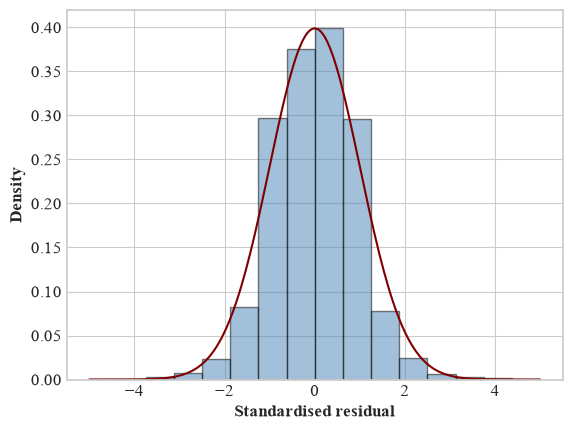

In [27]:
slm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_slm_std_residuals_plot')